This Code is for doing g2 for one ttbin file. Basically a test with a jupyter notebook. 

In [70]:
import TimeTagger
import pandas as pd
from tkinter import filedialog
import math
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize
from scipy.optimize import curve_fit
from tqdm.notebook import tqdm

# imports data into a pandas df
filename = ['./2023_09_20/toluene100000x_5uW/5/timetags_2023-09-20_152114.ttbin']
filereader = TimeTagger.FileReader(filename) # can take list of file names
data = pd.DataFrame()
while filereader.hasData():
    df = pd.DataFrame()
    t = filereader.getData(1000000) # randomly chosen
    df['Timestamps'] = t.getTimestamps() # ps
    df['Channel'] = t.getChannels() 
    df['Event Type'] = t.getEventTypes() # https://www.swabianinstruments.com/static/documentation/TimeTagger/api/TimeTaggerLibrary.html#TagType
    data = pd.concat([data, df])

# shift origin
data['Timestamps'] = data['Timestamps'] - data.iloc[0][0]
# checks for overflow
if sum(data['Event Type'] != 0):
    raise Exception("Overflow happened. Check data")

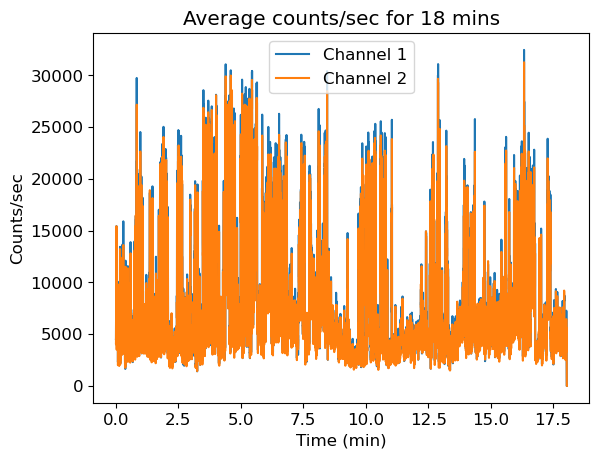

In [125]:
## plots avg counts in the two channels
ch1 = data.Channel.unique()[0]
ch2 = data.Channel.unique()[1]
ch1_tt = data[data['Channel'] == ch1]['Timestamps'] # in ps
ch2_tt = data[data['Channel'] == ch2]['Timestamps'] # in ps

# numpy faster than using pandas
ch1np = ch1_tt.to_numpy()
ch2np = ch2_tt.to_numpy()

# find last time over two channels
maxTime = 0
if max(ch1np) > maxTime:
    maxTime = max(ch1np)
if max(ch2np) > maxTime:
    maxTime = max(ch2np)
maxTime = int(math.ceil(maxTime/1e12)*1e12)

# group into bins of 100 milliseconds
seconds = []
for i in range(0, maxTime, int(1e11)):
    seconds.append(i)
s1 = np.histogram(ch1np,seconds)[0]*10
s2 = np.histogram(ch2np,seconds)[0]*10

# plot in terms of minutes
seconds.pop(0)
mins = [x/60/1e12 for x in seconds]
plt.plot(mins, s1, label = 'Channel '+ str(ch1))
plt.plot(mins, s2, label = 'Channel ' + str(ch2))
plt.xlabel("Time (min)")
plt.ylabel("Counts/sec")
plt.title('Average counts/sec for ' + str(round(maxTime*1e-12/60)) + " mins")
plt.legend()

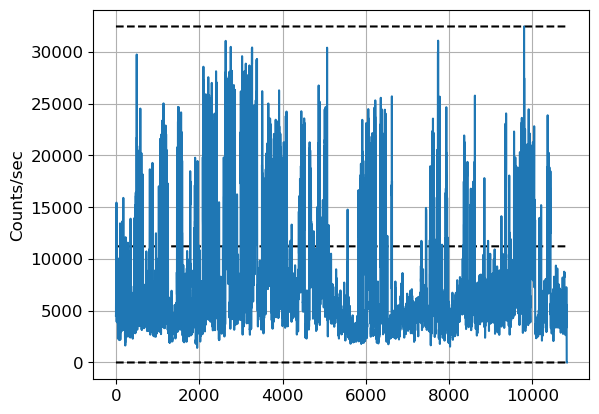

In [126]:
# algothorim to find the optimal split for the bright and dark
# https://en.wikipedia.org/wiki/Jenks_natural_breaks_optimization
def get_jenks_breaks(data_list2, number_class):
    data_list = np.copy(data_list2)
    data_list.sort()
    mat1 = []
    for i in range(len(data_list) + 1):
        temp = []
        for j in range(number_class + 1):
            temp.append(0)
        mat1.append(temp)
    mat2 = []
    for i in range(len(data_list) + 1):
        temp = []
        for j in range(number_class + 1):
            temp.append(0)
        mat2.append(temp)
    for i in range(1, number_class + 1):
        mat1[1][i] = 1
        mat2[1][i] = 0
        for j in range(2, len(data_list) + 1):
            mat2[j][i] = float('inf')
    v = 0.0
    for l in range(2, len(data_list) + 1):
        ss1 = 0.0
        ss2 = 0.0
        w = 0.0
        for m in range(1, l + 1):
            i3 = l - m + 1
            val = float(data_list[i3 - 1])
            ss2 += val * val
            ss1 += val
            w += 1
            v = ss2 - (ss1 * ss1) / w
            i4 = i3 - 1
            if i4 != 0:
                for j in range(2, number_class + 1):
                    if mat2[l][j] >= (v + mat2[i4][j - 1]):
                        mat1[l][j] = i3
                        mat2[l][j] = v + mat2[i4][j - 1]
        mat1[l][1] = 1
        mat2[l][1] = v
    k = len(data_list)
    kclass = []
    for i in range(number_class + 1):
        kclass.append(min(data_list))
    kclass[number_class] = float(data_list[len(data_list) - 1])
    count_num = number_class
    while count_num >= 2:  # print "rank = " + str(mat1[k][count_num])
        idx = int((mat1[k][count_num]) - 2)
        # print "val = " + str(data_list[idx])
        kclass[count_num - 1] = data_list[idx]
        k = int((mat1[k][count_num] - 1))
        count_num -= 1
    return kclass

breaks = get_jenks_breaks(s1, 2)

for line in breaks:
    plt.plot([line for _ in range(len(s1))], 'k--')

plt.plot(s1)
plt.ylabel("Counts/sec")
plt.grid(True)
plt.show()

In [118]:
# this is for splitting the time tag data into the bright and dark states
brightCounts1 = []
brightCounts2 = []
dimCounts1 = []
dimCounts2 = []
index1 = 0
index2 = 0
l1 = len(ch1np)
l2 = len(ch2np)
for i in range(0, len(seconds)):
    if s1[i] >= breaks[1]:
        while index1 < l1 and ch1np[index1] < seconds[i]:
            brightCounts1.append(ch1np[index1])
            index1 += 1
        while index2 < l2 and ch2np[index2] < seconds[i]:
            brightCounts2.append(ch2np[index2])
            index2 += 1
    else:
        while index1 < l1 and ch1np[index1] < seconds[i]:
            dimCounts1.append(ch1np[index1])
            index1 += 1
        while index2 < l2 and ch2np[index2] < seconds[i]:
            dimCounts2.append(ch2np[index2])
            index2 += 1

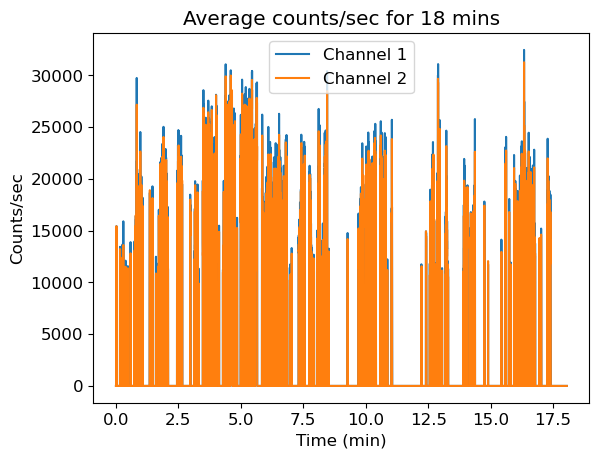

In [119]:
# find last time over two channels
maxTimebd = maxTime

# group into bins of 100 milliseconds
seconds = []
for i in range(0, maxTimebd, int(1e11)):
    seconds.append(i)
s11 = np.histogram(brightCounts1,seconds)[0]*10
s22 = np.histogram(brightCounts2,seconds)[0]*10

# plot in terms of minutes
seconds.pop(0)
mins = [x/60/1e12 for x in seconds]
plt.plot(mins, s11, label = 'Channel '+ str(ch1))
plt.plot(mins, s22, label = 'Channel ' + str(ch2))
plt.xlabel("Time (min)")
plt.ylabel("Counts/sec")
plt.title('Average counts/sec for ' + str(round(maxTimebd*1e-12/60)) + " mins")
plt.legend()

In [120]:
maxTime = maxTimebd
ch2np = brightCounts2
ch1np = brightCounts1

In [121]:
# unnonormalized g2 like the matlab that todd wrote

# binning the data
binsize = 1e-9 # in sec
binps = binsize/1e-12 # in ps
window = np.array([-1, 1])*200e-9 # in sec
winps = window/1e-12 # in ps
timeDiffs = []
kloopmin = 0
kloopmax = len(ch2np)

for j in tqdm(range(len(ch1np))):
    for k in range(kloopmin, kloopmax):
        tD = ch2np[k] - ch1np[j]

        # this is for speeding up the binning
        # checks if difference is within the window specified for speedup
        if tD <= winps[0]:
            kloopmin = k # only have to look at larger time diffs
        elif tD >= winps[1]:
            break # only have to look at smaller time diffs
        else:
            timeDiffs.append(tD)


  0%|          | 0/3969521 [00:00<?, ?it/s]

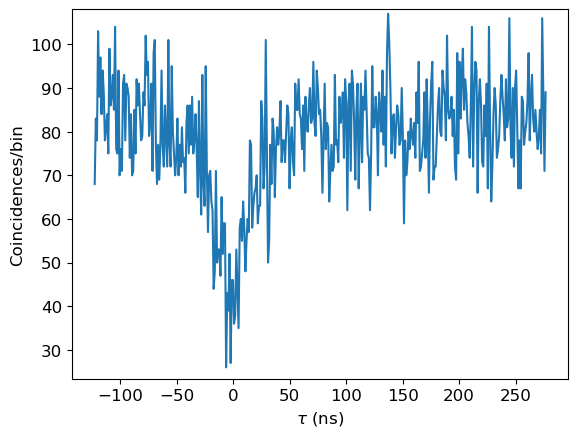

In [122]:
# plotting the histogram of the binned data unnormalized
counts,bins = np.histogram(timeDiffs, bins = int((winps[1] - winps[0])/binps), range = (winps[0], winps[1]))
bins = bins*1e-3 # to ns
bincenter = [(bins[i + 1] + bins[i])/2 for i in range(len(bins)-1)] # get the average value of the bin 
bincenter = np.array(bincenter) +77 # g2(0) should be at 38 ns
plt.plot(bincenter, counts)
plt.ylabel("Coincidences/bin")
plt.xlabel(r'$\tau$ (ns)')
plt.ylim([min(counts)*0.9, max(counts)*1.01])
plt.rcParams.update({'font.size':12})

         Current function value: 0.000000
         Iterations: 3
         Function evaluations: 122
         Gradient evaluations: 55


Text(0.5, 1.0, '$g^{(2)}(\\tau)$ - 18 mins')

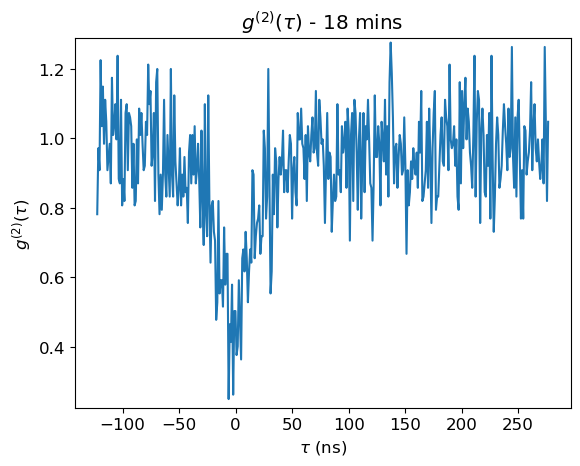

In [123]:
## normalization based on https://journals.aps.org/prxquantum/abstract/10.1103/PRXQuantum.4.010202#:~:text=Photon%2Demission%2Dcorrelation%20spectroscopy%20is,key%20property%20for%20quantum%20technology.
# dont need to do timing jitter correction since my rms gaussian timing jitter is 54.3 ps << lifetime of emitter
totalTime = maxTime*1e-12 # in s
avg1 = np.mean(s1)
avg2 = np.mean(s2)
# ASK FOR USER INPUT
avgbk1 = 350
avgbk2 = 350


# making sure the higher count channel is in channel 1
if avg2 > avg1:
    avg1, avg2 = avg2, avg1
    avgbk1, avgbk2 = avgbk2, avgbk1

# since the beam splitter is about 41.6/58.4, the normalization is not trivial
# Also, since the microscope drifts, the avg count rate decreases over time so have to optimize
# over the count rate to get a g2 at the wings of 1
def avgmin(x):
    a1 = avg1 + avg1*x/(avg1+avg2)
    a2 = avg2 + avg2*x/(avg1+avg2)
    cn = counts/(a1*a2*totalTime*binsize)
    rho1 = a1/(a1 + avgbk1)
    rho2 = a2/(a2 + avgbk2)
    g2 = (cn + rho1*rho2 - 1)/(rho1*rho2)
    return abs(np.mean(g2[1:50])-1)
resd = minimize(avgmin, 0, options={'disp': True})

# taking optimal counts and plotting the g2 
a1 = avg1 + avg1*resd.x/(avg1+avg2)
a2 = avg2 + avg2*resd.x/(avg1+avg2)
cn = counts/(a1*a2*totalTime*binsize)
rho1 = a1/(a1 + avgbk1)
rho2 = a2/(a2 + avgbk2)
g2 = (cn + rho1*rho2 - 1)/(rho1*rho2)
plt.plot(bincenter, g2)
plt.ylabel(r"$g^{(2)}(\tau)$")
plt.xlabel(r'$\tau$ (ns)')
plt.ylim([min(g2)*0.9, max(g2)*1.01])
plt.rcParams.update({'font.size':12})
plt.title(r"$g^{(2)}(\tau)$ - " + str(round(maxTime*1e-12/60)) + " mins")

params[ 0.6577274  21.15352225]


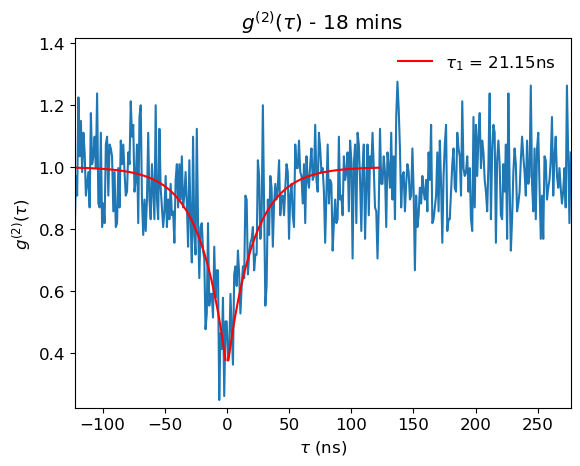

In [124]:
# fitting
minindex = (np.abs(bincenter)).argmin()
shortbin = bincenter[:minindex]
shortg2 = g2[:minindex]
shortbin = shortbin*-1

fitcase = "single"
def fitg2(fitcase):
    match fitcase:
        case "double":
            def double(x, a, b, c, d):
                return 1 - a*np.exp(-x/b) + c*np.exp(-x/d)
            parameters, covariance = curve_fit(double, shortbin, shortg2, p0 = [0.1,12,0.1,100], bounds = ((0, 5,0,20),(1,13,1,1000)))
            fit = double(shortbin, *parameters)
            return fit, parameters 
        case "single": 
            def single(x, a, b):
                return 1 - a*np.exp(-x/b)
            parameters, covariance = curve_fit(single, shortbin, shortg2, p0 = [0.1,12], bounds = ((-1, 1),(1,1000)))
            fit = single(shortbin, *parameters)
            return fit, parameters
fittg2, parameters = fitg2(fitcase)
plt.plot(bincenter, g2)
if len(parameters) > 2:
    plt.plot(shortbin, fittg2, color = 'red', label = r"$\tau_1$ = "+str(round(parameters[1],2)) + r"ns, $\tau_2$ = " + str(round(parameters[3],2))+"ns")
else:
    plt.plot(shortbin, fittg2, color = 'red', label = r"$\tau_1$ = "+str(round(parameters[1],2))+"ns")
plt.plot(-1*shortbin, fittg2, color = 'red')
plt.xlim([bincenter[0], bincenter[-1]])
plt.ylabel(r"$g^{(2)}(\tau)$")
plt.xlabel(r'$\tau$ (ns)')
plt.ylim([min(g2)*0.9, max(g2)*1.11])
plt.rcParams.update({'font.size':12})
plt.title(r"$g^{(2)}(\tau)$ - " + str(round(maxTime*1e-12/60)) + " mins")
plt.legend(frameon = False)
print("params" + str(parameters))
